# 实验环境

本实验基于 Python 环境，利用 Scikit-learn 中的高斯混合模型（Gaussian Mixture Model, GMM）实现基于 EM（Expectation-Maximization）算法的参数学习。

实验运行环境如下：

| 软件/库 | 版本 | 作用 |
|:---|:---|:---|
| Python | - | 实验运行环境 |
| JupyterLab | 4.3.4 | 提供Notebook交互式实验环境 |
| NumPy | 2.1.3 | 数值计算、矩阵运算 |
| Pandas | 2.2.3 | 数据读取、表格展示与数据处理 |
| Matplotlib | 3.10.0 | 数据可视化与结果绘图 |
| Scikit-learn | 1.6.1 | 提供GMM模型、PCA降维以及聚类评价指标 |
| SciPy | 1.15.3 | 科学计算与概率计算支持 |

# 基于高斯混合模型（GMM）的EM算法实验

## 实验目的

本实验旨在通过真实数据集理解EM（Expectation-Maximization）算法在高斯混合模型（Gaussian Mixture Model, GMM）中的应用。

通过本实验，学习：

1. GMM模型的概率生成思想；
2. EM算法中E步和M步的作用；
3. 利用sklearn实现基于EM算法的GMM模型训练；
4. 分析模型学习得到的：
   - 高斯分布参数；
   - 隐变量后验概率；
   - 聚类结果；
5. 通过可视化直观理解EM算法的优化过程。

# 1. 实验原理

## 1.1 高斯混合模型（GMM）

GMM假设数据由多个高斯分布混合生成：

$$
p(x)=\sum_{k=1}^{K}\pi_k
N(x|\mu_k,\Sigma_k)
$$


其中：

- $K$：高斯分布数量；
- $\pi_k$：第k个高斯分布的混合权重；
- $\mu_k$：均值向量；
- $\Sigma_k$：协方差矩阵。


每一个样本实际上来自某一个未知的高斯分布，因此存在隐藏变量：

$$
z_i \in \{1,2,...,K\}
$$


该隐藏变量表示：

> 第i个样本属于哪一个高斯分布。

---

## 1.2 EM算法


由于隐藏变量无法直接观测，因此不能直接利用最大似然估计求解参数。

EM算法通过不断迭代两个步骤优化模型：

### E-step（Expectation）

根据当前模型参数：

$$
\theta=(\pi,\mu,\Sigma)
$$

计算隐藏变量的后验概率：

$$
P(z_i=k|x_i)
$$


即：

> 当前样本属于每个高斯分布的概率。


---

### M-step（Maximization）

利用E步计算得到的概率，重新估计：

- 均值 $\mu$
- 协方差 $\Sigma$
- 混合比例 $\pi$


使模型似然函数最大。


---

因此EM算法流程：

初始化参数

↓

E-step

计算隐变量概率

↓

M-step

更新模型参数

↓

判断是否收敛

↓

输出最终GMM模型

1.导入实验环境

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt


from sklearn.datasets import load_iris
from sklearn.mixture import GaussianMixture

from sklearn.metrics import adjusted_rand_score


# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 2. 数据集介绍

本实验采用经典公开数据集：

## Iris鸢尾花数据集


Iris数据集包含150个样本，每个样本包含4个特征：

- 花萼长度
- 花萼宽度
- 花瓣长度
- 花瓣宽度


原始数据包含3个类别：

- Setosa
- Versicolor
- Virginica


但是：

> 在GMM无监督学习过程中，不使用真实类别标签。


真实标签仅用于最后评价聚类效果。


本实验为了方便二维可视化，选择：

- 花萼长度
- 花萼宽度

作为输入特征。

In [2]:
iris = load_iris()


X_all = iris.data
y_true = iris.target


# 选择两个特征用于二维展示
X = X_all[:, :2]


print("数据维度:")
print(X.shape)


print("类别数量:")
print(len(np.unique(y_true)))

数据维度:
(150, 2)
类别数量:
3


In [3]:
plt.figure(figsize=(6,5))


plt.scatter(
    X[:,0],
    X[:,1],
    c=y_true
)


plt.xlabel("Sepal length")
plt.ylabel("Sepal width")

plt.title("Original Iris Dataset")


plt.show()

<Figure size 600x500 with 1 Axes>

# 4. 建立高斯混合模型（GMM）


前面已经观察了数据分布。

下面假设：

> Iris数据由3个不同的高斯分布混合产生。


因此建立：

$$
K=3
$$


的GMM模型。


模型参数包括：

|参数|含义|
|-|-|
|$\pi_k$|第k个高斯分布比例|
|$\mu_k$|第k个高斯分布均值|
|$\Sigma_k$|第k个高斯分布协方差|


sklearn中的：

`GaussianMixture`

内部采用EM算法优化这些参数。

In [4]:
# 创建GMM模型

gmm = GaussianMixture(
    n_components=3,
    covariance_type='full',
    max_iter=100,
    random_state=42
)

# 使用EM算法训练模型

gmm.fit(X)


print("模型训练完成")
print("EM迭代次数:", gmm.n_iter_)

模型训练完成
EM迭代次数: 8


# 5. 查看EM算法学习得到的模型参数


EM算法最终学习得到：

## 1. 高斯分布均值

$$
\mu_k
$$


表示每个类别中心。


## 2. 协方差矩阵

$$
\Sigma_k
$$


表示数据分布范围和方向。


## 3. 混合权重

$$
\pi_k
$$


表示每个高斯分布所占比例。

In [5]:
means_df = pd.DataFrame(
    gmm.means_,
    columns=[
        "花萼长度均值",
        "花萼宽度均值"
    ]
)


means_df.index = [
    "高斯分布1",
    "高斯分布2",
    "高斯分布3"
]


means_df

,花萼长度均值,花萼宽度均值
高斯分布1,6.680556,3.028496
高斯分布2,5.900998,2.743875
高斯分布3,5.015079,3.451446


In [6]:
weights_df = pd.DataFrame(
    gmm.weights_,
    columns=["混合比例"]
)


weights_df.index=[
    "高斯分布1",
    "高斯分布2",
    "高斯分布3"
]


weights_df

,混合比例
高斯分布1,0.294741
高斯分布2,0.380813
高斯分布3,0.324446


In [7]:
for i, cov in enumerate(gmm.covariances_):

    print(f"高斯分布{i+1} 协方差矩阵:")
    
    cov_df=pd.DataFrame(
        cov,
        columns=[
            "花萼长度",
            "花萼宽度"
        ],
        index=[
            "花萼长度",
            "花萼宽度"
        ]
    )
    
    display(cov_df)


高斯分布1 协方差矩阵:


,花萼长度,花萼宽度
花萼长度,0.361535,0.051597
花萼宽度,0.051597,0.089279


高斯分布2 协方差矩阵:


,花萼长度,花萼宽度
花萼长度,0.276711,0.088970
花萼宽度,0.088970,0.093892


高斯分布3 协方差矩阵:


,花萼长度,花萼宽度
花萼长度,0.119447,0.088356
花萼宽度,0.088356,0.118934


# 6. EM算法中的隐变量分析

在GMM模型中，每一个样本都有一个隐藏变量：
$$
z_i
$$

表示：

> 第i个样本来自哪个高斯分布。


但是由于真实类别未知，因此EM算法不会直接给出：
类别 = 1
类别 = 2
类别 = 3
而是计算：
$$
P(z_i=k|x_i)
$$
即：
> 样本属于第k个高斯分布的概率。


例如：

|样本|高斯分布1|高斯分布2|高斯分布3|
|-|-|-|-|
|样本1|0.95|0.05|0.00|
|样本2|0.10|0.80|0.10|


这体现了GMM的特点：

**软聚类（Soft Clustering）**

而不是传统K-means的：

**硬聚类（Hard Clustering）**

In [8]:
# 使用训练好的GMM模型计算后验概率

prob = gmm.predict_proba(X)


print("隐变量概率矩阵大小:")
print(prob.shape)

隐变量概率矩阵大小:
(150, 3)


前10个样本的概率：

In [9]:
prob_df = pd.DataFrame(
    prob[:10],
    columns=[
        "属于高斯分布1概率",
        "属于高斯分布2概率",
        "属于高斯分布3概率"
    ]
)


prob_df.index=[
    f"样本{i+1}" 
    for i in range(10)
]


prob_df

,属于高斯分布1概率,属于高斯分布2概率,属于高斯分布3概率
样本1,0.000709,0.000086,0.999205
样本2,0.013630,0.031249,0.955121
样本3,0.000802,0.000342,0.998856
样本4,0.000969,0.000694,0.998337
样本5,0.000194,0.000009,0.999797
样本6,0.000118,0.000002,0.999880
样本7,0.000263,0.000018,0.999720
样本8,0.000881,0.000173,0.998946
样本9,0.001326,0.002773,0.995901
样本10,0.005578,0.006842,0.987580


# 7. 根据隐变量概率确定最终类别
虽然GMM输出的是概率：
$$
P(z_i=k|x_i)
$$

但是为了进行聚类结果展示，

通常选择概率最大的类别：
$$
label_i=
argmax_kP(z_i=k|x_i)
$$

如果：

$$
P(z_i)=
(0.1,0.8,0.1)
$$


则认为：

该样本属于：
高斯分布2

In [10]:
# 最大概率对应的类别

y_pred = gmm.predict(X)


print(y_pred[:20])

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


# 8. GMM聚类结果可视化


下面绘制：

- 不同颜色的数据点：
    表示不同高斯分布

- 五角星：
    表示EM算法学习得到的高斯中心


通过图像可以观察：

EM算法自动发现数据中的潜在结构。

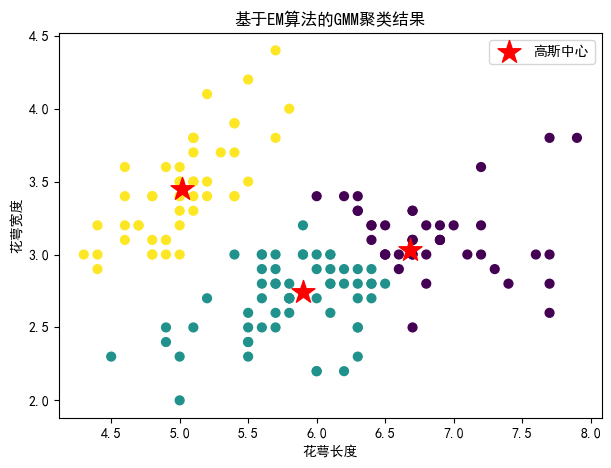

In [11]:
plt.figure(figsize=(7,5))


plt.scatter(
    X[:,0],
    X[:,1],
    c=y_pred,
    s=40
)


# 绘制高斯中心

plt.scatter(
    gmm.means_[:,0],
    gmm.means_[:,1],
    marker="*",
    s=300,
    c="red",
    label="高斯中心"
)


plt.xlabel("花萼长度")
plt.ylabel("花萼宽度")


plt.title(
    "基于EM算法的GMM聚类结果"
)


plt.legend()


plt.show()

# 9. 聚类效果评价

虽然GMM属于无监督学习，

但是Iris数据集提供真实类别标签。

因此可以使用：

调整兰德指数（Adjusted Rand Index, ARI）

评价聚类结果：
$$
ARI \in [-1,1]
$$

越接近1：

表示聚类结果与真实类别越一致。
由于本例只使用：
花萼长度
花萼宽度
两个特征，因此类别分离并不是非常明显。

如果使用全部4个特征：

通常效果会更好。

In [12]:
ari = adjusted_rand_score(
    y_true,
    y_pred
)


print(
    "调整兰德指数ARI:",
    ari
)

调整兰德指数ARI: 0.5548493819740281


# 10. 使用全部特征重新训练GMM
前面的实验为了展示二维分布，

只使用两个特征。

实际建模时可以利用全部特征：

- 花萼长度
- 花萼宽度
- 花瓣长度
- 花瓣宽度

重新训练GMM模型，得到包含4维特征信息的模型。

此时模型拥有更多信息，
聚类效果通常会提升。

In [13]:
gmm_full = GaussianMixture(
    n_components=3,
    covariance_type="full",
    max_iter=100,
    random_state=42
)


gmm_full.fit(X_all)


y_pred_full = gmm_full.predict(X_all)



ari_full = adjusted_rand_score(
    y_true,
    y_pred_full
)


print(
    "使用全部特征后的ARI:",
    ari_full
)

使用全部特征后的ARI: 0.9038742317748124


EM迭代次数: 8
最终平均对数似然: -1.4987505566235169
